In [1]:
# Breast Cancer Detection using Machine Learning

## Module 1: Understanding the Dataset

In [2]:
import pandas as pd


In [4]:
df=pd.read_csv(r"C:\Users\PC\OneDrive\Desktop\breast-cancer detection\data\data.csv")

In [5]:
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df.shape

(569, 33)

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [17]:
df["diagnosis"].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [22]:
df=df.drop(columns=["id","Unnamed: 32"])

In [23]:
df.shape

(569, 31)

In [26]:
df['diagnosis']=df['diagnosis'].map({
    "M":1,
    "B":0
})
    

In [27]:
df["diagnosis"].head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [29]:
X=df.drop("diagnosis",axis=1)

In [30]:
y = df["diagnosis"]

In [31]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [33]:
X.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

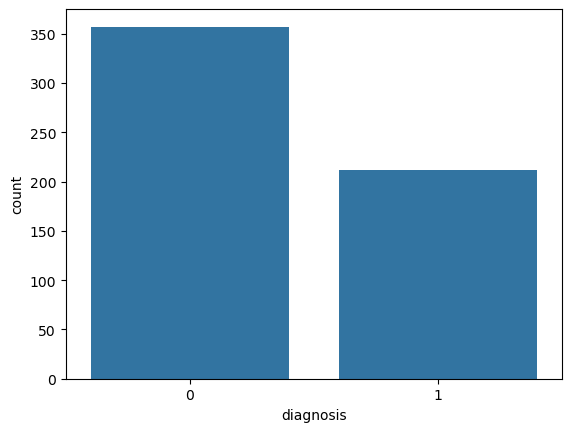

In [35]:
sns.countplot(x="diagnosis",data=df)
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [37]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64

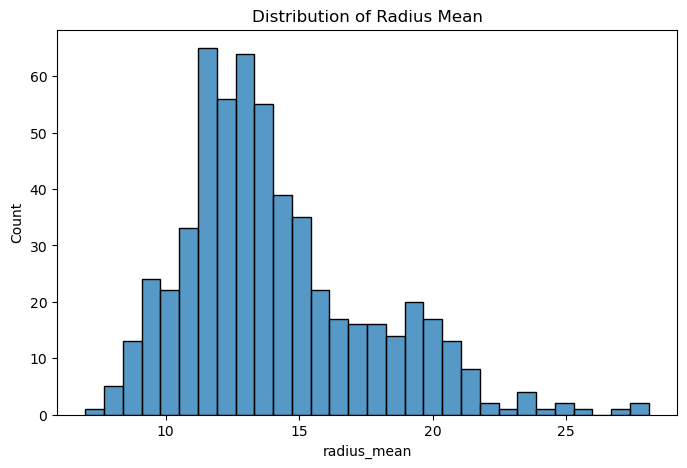

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["radius_mean"], bins=30)

plt.title("Distribution of Radius Mean")
plt.show()

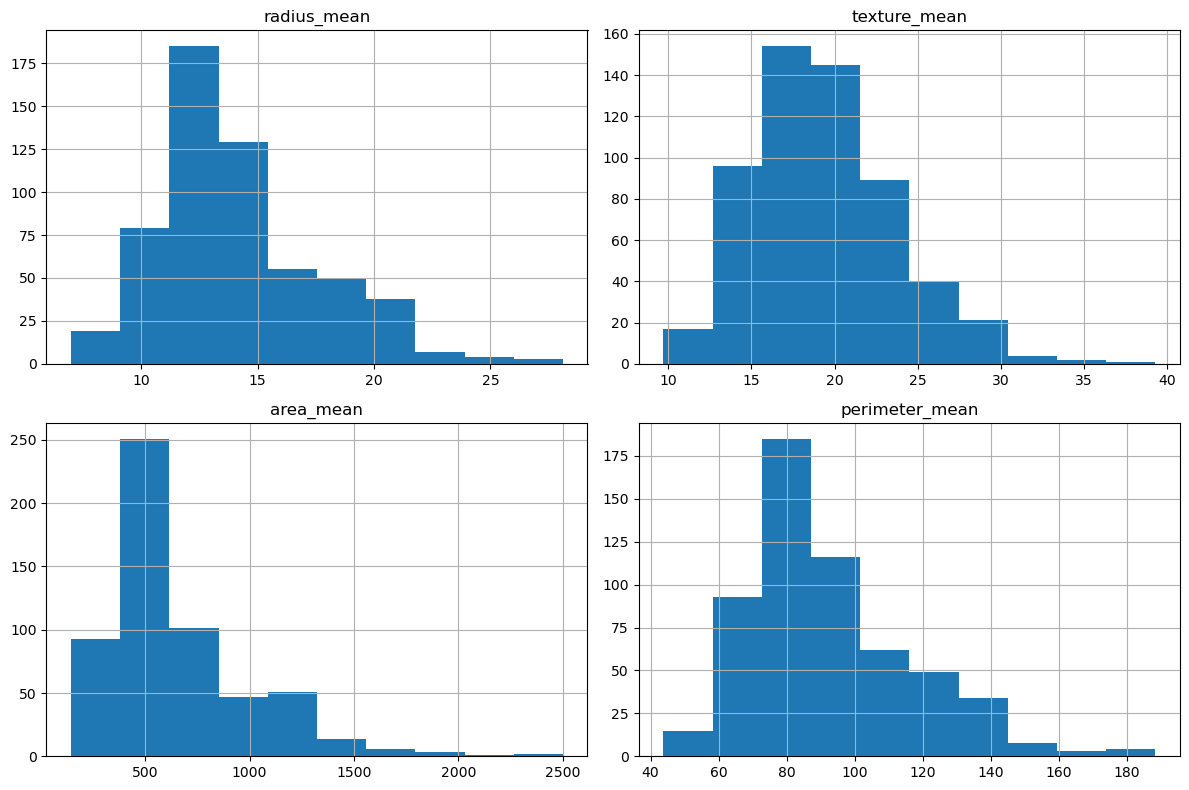

In [ ]:
features = [
    "radius_mean",
    "texture_mean",
    "area_mean",
    "perimeter_mean"
]

df[features].hist(figsiz0e=(12,8))

plt.tight_layout()
plt.show()

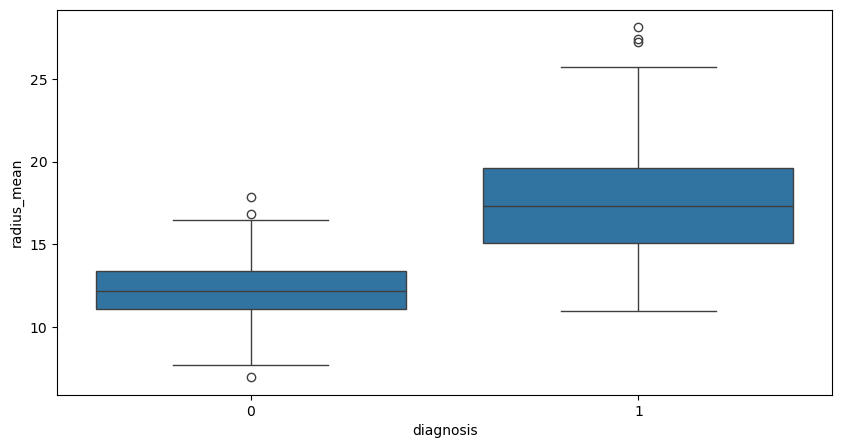

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(x="diagnosis",y="radius_mean",data=df)

plt.show()

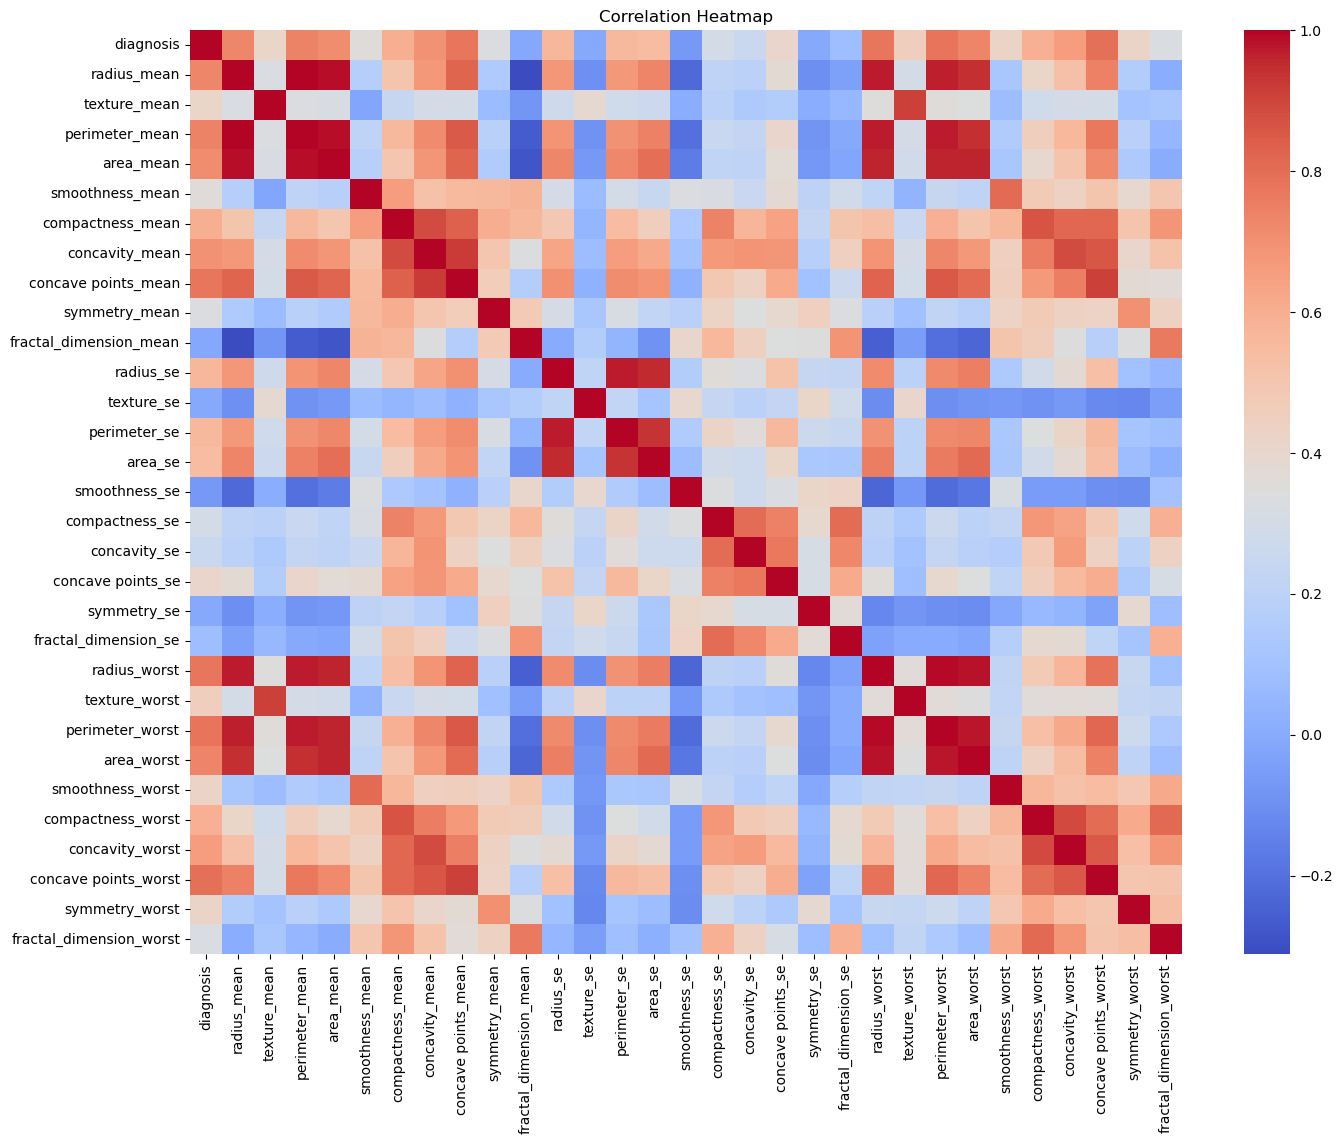

In [43]:
plt.figure(figsize=(16,12))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [48]:
corr_target = df.corr()["diagnosis"]

corr_target.sort_values(ascending=False).head(10)

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64

In [49]:
#traing model
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(455, 30)
(114, 30)
(455,)
(114,)


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [53]:
X_test_scaled = scaler.transform(X_test) #not fit here

In [54]:
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
3,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
4,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


In [55]:
X_train_scaled.mean()

np.float64(1.6006731959430828e-17)

In [56]:
X_train_scaled.std()

np.float64(1.0)

In [57]:
#logistic regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=5000
)

In [58]:
log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [59]:
y_pred_log = log_model.predict(
    X_test_scaled
)

In [60]:
print(y_pred_log[:10])

[0 1 0 1 1 0 1 0 0 0]


In [61]:
print(y_test[:10].values)

[0 1 0 1 0 0 1 0 0 0]


In [62]:
#calculate accuracy
from sklearn.metrics import accuracy_score

In [65]:
accuracy_log = accuracy_score(
    y_test,
    y_pred_log
)

print(f"{accuracy_log*100:2f}")

96.491228


In [66]:
#test probabiloty

In [67]:
log_model.predict_proba(
    X_test_scaled
)[:5]

array([[9.99635432e-01, 3.64568116e-04],
       [1.07465986e-08, 9.99999989e-01],
       [9.57432053e-01, 4.25679471e-02],
       [4.23812678e-01, 5.76187322e-01],
       [4.90844511e-01, 5.09155489e-01]])

In [68]:
#feature importance
log_model.coef_

array([[ 0.36115007,  0.4822194 ,  0.35315987,  0.43995028,  0.35062156,
        -0.43954615,  0.78229835,  0.95281283, -0.16399087, -0.08086512,
         1.23332517, -0.40761126,  0.74829471,  0.90902906,  0.24799098,
        -0.9069248 , -0.09234069,  0.48208908, -0.33065773, -0.59387632,
         0.89696783,  1.43409317,  0.72311148,  0.90047661,  0.42020675,
        -0.17348751,  0.9114058 ,  0.70399881,  1.06126366,  0.05486988]])

In [69]:
#feature importance table
coef_df=pd.DataFrame({
    "feature":X.columns,
    "Coefficients":log_model.coef_[0]
})

coef_df.sort_values(
    by="Coefficients",
    ascending=False
).head(10)

,feature,Coefficients
21,texture_worst,1.434093
10,radius_se,1.233325
28,symmetry_worst,1.061264
7,concave points_mean,0.952813
26,concavity_worst,0.911406
13,area_se,0.909029
23,area_worst,0.900477
20,radius_worst,0.896968
6,concavity_mean,0.782298
12,perimeter_se,0.748295


In [70]:
#model evaluvation
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

cm

array([[71,  1],
       [ 3, 39]])

In [71]:
TN, FP, FN, TP = cm.ravel()

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)

True Negative : 71
False Positive: 1
False Negative: 3
True Positive : 39


In [72]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_log)

print("Precision:", precision)

Precision: 0.975


In [73]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_log)

print("Recall:", recall)

Recall: 0.9285714285714286


In [74]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred_log)

print("F1 Score:", f1)

F1 Score: 0.9512195121951219


In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [76]:
#using KNN algorithm
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [77]:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.956140350877193


In [78]:
#use calassification report or separtely f1 score ,precison,recall etc
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [79]:
#FINDING BEST K VALUE FOR KNN BEFORE PCA

In [80]:
k_values = []
accuracies = []

In [81]:
#for eack k getting there acuracy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    k_values.append(k)
    accuracies.append(accuracy)

In [82]:
for k, acc in zip(k_values, accuracies):
    print(f"K={k}, Accuracy={acc:.4f}")

K=1, Accuracy=0.9298
K=2, Accuracy=0.9123
K=3, Accuracy=0.9386
K=4, Accuracy=0.9386
K=5, Accuracy=0.9561
K=6, Accuracy=0.9474
K=7, Accuracy=0.9561
K=8, Accuracy=0.9474
K=9, Accuracy=0.9474
K=10, Accuracy=0.9474
K=11, Accuracy=0.9474
K=12, Accuracy=0.9474
K=13, Accuracy=0.9474
K=14, Accuracy=0.9386
K=15, Accuracy=0.9474
K=16, Accuracy=0.9386
K=17, Accuracy=0.9386
K=18, Accuracy=0.9386
K=19, Accuracy=0.9386
K=20, Accuracy=0.9386


In [83]:
best_accuracy = max(accuracies)

best_k = k_values[accuracies.index(best_accuracy)]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 5
Best Accuracy: 0.956140350877193


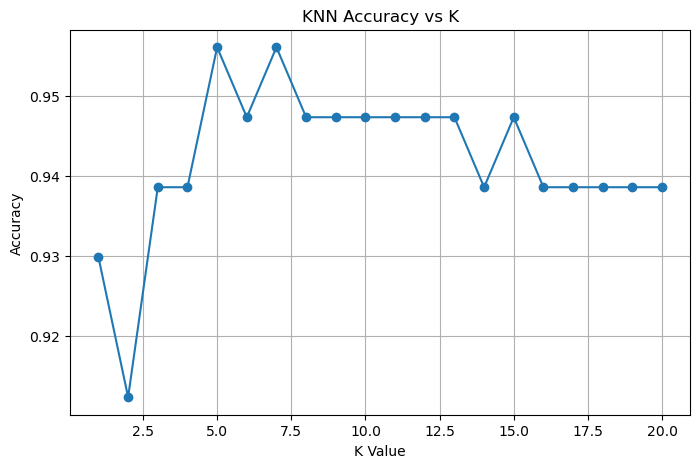

In [84]:
#visulisation
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("KNN Accuracy vs K")

plt.grid(True)

plt.show()

In [85]:
#if needed  re evalution the model with replace actual k
best_knn = KNeighborsClassifier(n_neighbors=7)

best_knn.fit(X_train_scaled, y_train)

y_pred_best_knn = best_knn.predict(X_test_scaled)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best_knn))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [86]:
#PCA-> always scale it before uisng pca(pca=> maximises the variance
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train_scaled)
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[4.45935222e-01 1.85452555e-01 9.58464121e-02 6.59376825e-02
 5.62228616e-02 3.98848772e-02 2.21449317e-02 1.61400564e-02
 1.28478896e-02 1.16566138e-02 1.00835994e-02 9.05534747e-03
 7.92635285e-03 4.79482101e-03 3.04107016e-03 2.51299401e-03
 1.97524871e-03 1.74413404e-03 1.57346560e-03 1.05152270e-03
 9.95539341e-04 7.95814888e-04 7.84034550e-04 5.31246275e-04
 5.11862282e-04 2.64113057e-04 2.09992404e-04 5.03306942e-05
 2.52827614e-05 4.12638742e-06]


In [87]:
#cumulative variance=> imp pca
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)


[0.44593522 0.63138778 0.72723419 0.79317187 0.84939473 0.88927961
 0.91142454 0.9275646  0.94041249 0.9520691  0.9621527  0.97120805
 0.9791344  0.98392922 0.98697029 0.98948329 0.99145854 0.99320267
 0.99477613 0.99582766 0.9968232  0.99761901 0.99840305 0.99893429
 0.99944615 0.99971027 0.99992026 0.99997059 0.99999587 1.        ]


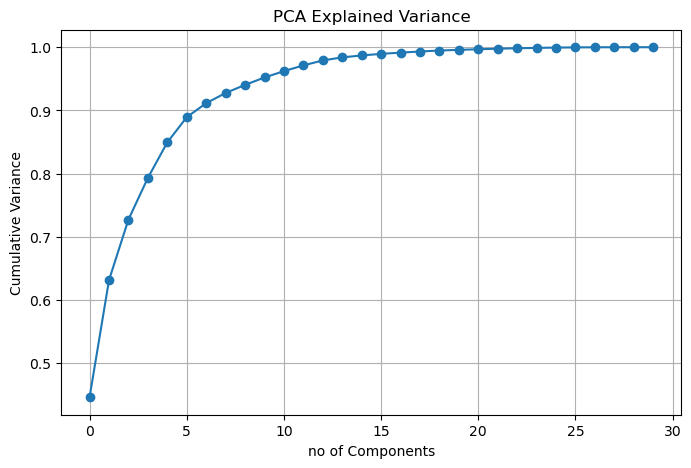

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(
    cumulative_variance,
    marker='o'
)
plt.xlabel("no of Components")
plt.ylabel("Cumulative Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [91]:
#trance for using PCA
pca_95 = PCA(n_components=0.95)
pca_95.fit(X_train_scaled)

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [92]:
X_train_pca = pca_95.transform(X_train_scaled)

X_test_pca = pca_95.transform(X_test_scaled)


In [94]:
print(X_train_scaled.shape)
print(X_train_pca.shape)

(455, 30)
(455, 10)


In [95]:
print(
    "Components selected:",
    pca_95.n_components_
)

Components selected: 10


In [96]:
from sklearn.neighbors import KNeighborsClassifier

knn_pca = KNeighborsClassifier(
    n_neighbors=best_k
)

In [97]:
knn_pca.fit(
    X_train_pca,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [98]:
y_pred_knn_pca=knn_pca.predict(
    X_test_pca
)

In [101]:
from sklearn.metrics import accuracy_score

accuracy_knn_pca = accuracy_score(
    y_test,
    y_pred_knn_pca
)

print(
    "KNN PCA Accuracy:",
    accuracy_knn_pca
)

KNN PCA Accuracy: 0.956140350877193


In [100]:
#confustion matrix
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_knn_pca
    )
)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [102]:
#compare before pca and after pca
print("Original KNN :", accuracy_knn)

print("KNN After PCA:", accuracy_knn_pca)

Original KNN : 0.956140350877193
KNN After PCA: 0.956140350877193


In [104]:
#logistic regression after pca
from sklearn.linear_model import LogisticRegression
log_pca=LogisticRegression(
    random_state=42
)
log_pca.fit(
    X_train_pca,
    y_train
)
y_pred_log_pca = log_pca.predict(
    X_test_pca
)

In [105]:
#acuracy score and confustion matrix
from sklearn.metrics import accuracy_score

accuracy_log_pca = accuracy_score(
    y_test,
    y_pred_log_pca
)

print(
    "Logistic PCA Accuracy:",
    accuracy_log_pca
)

Logistic PCA Accuracy: 0.9736842105263158


In [106]:
from sklearn.metrics import confusion_matrix

cm_log_pca = confusion_matrix(
    y_test,
    y_pred_log_pca
)

print(cm_log_pca)

[[72  0]
 [ 3 39]]


In [107]:
#find all precison recall etc
print(
    "Original Logistic:",
    accuracy_log
)

print(
    "Logistic + PCA:",
    accuracy_log_pca
)

Original Logistic: 0.9649122807017544
Logistic + PCA: 0.9736842105263158


#model comparison and completion

In [112]:
#knn
from sklearn.metrics import precision_score, recall_score, f1_score

precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1:", f1_knn)

#knn+pca
from sklearn.metrics import precision_score, recall_score, f1_score

precision_knn_pca = precision_score(y_test, y_pred_knn_pca)
recall_knn_pca = recall_score(y_test, y_pred_knn_pca)
f1_knn_pca = f1_score(y_test, y_pred_knn_pca)

print("Precision:", precision_knn_pca)
print("Recall:", recall_knn_pca)
print("F1:", f1_knn_pca)

#log+pca
from sklearn.metrics import precision_score, recall_score, f1_score

precision_log_pca = precision_score(y_test, y_pred_log_pca)
recall_log_pca = recall_score(y_test, y_pred_log_pca)
f1_log_pca = f1_score(y_test, y_pred_log_pca)

print("Precision:", precision_log_pca)
print("Recall:", recall_log_pca)
print("F1:", f1_log_pca)

#model comparison and completion
precision_log = precision
recall_log = recall
f1_log = f1



Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1: 0.9382716049382716
Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1: 0.9382716049382716
Precision: 1.0
Recall: 0.9285714285714286
F1: 0.9629629629629629


In [113]:
#comaprison btw models
comparison = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "KNN + PCA",
        "Logistic + PCA"
    ],

    "Accuracy": [
        accuracy_log,
        accuracy_knn,
        accuracy_knn_pca,
        accuracy_log_pca
    ],

    "Precision": [
        precision_log,
        precision_knn,
        precision_knn_pca,
        precision_log_pca
    ],

    "Recall": [
        recall_log,
        recall_knn,
        recall_knn_pca,
        recall_log_pca
    ],

    "F1 Score": [
        f1_log,
        f1_knn,
        f1_knn_pca,
        f1_log_pca
    ]
}


In [114]:
comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
1,KNN,0.956140,0.974359,0.904762,0.938272
2,KNN + PCA,0.956140,0.974359,0.904762,0.938272
3,Logistic + PCA,0.973684,1.000000,0.928571,0.962963


In [115]:
comparison_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
3,Logistic + PCA,0.973684,1.000000,0.928571,0.962963
1,KNN,0.956140,0.974359,0.904762,0.938272
2,KNN + PCA,0.956140,0.974359,0.904762,0.938272


In [116]:
best_recall_model = comparison_df.loc[
    comparison_df["Recall"].idxmax()
]

print(best_recall_model)

Model        Logistic Regression
Accuracy                0.964912
Precision                  0.975
Recall                  0.928571
F1 Score                 0.95122
Name: 0, dtype: object


In [117]:
# building feature imp porperly
coefficients = log_model.coef_[0]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
21,texture_worst,1.434093
10,radius_se,1.233325
28,symmetry_worst,1.061264
7,concave points_mean,0.952813
26,concavity_worst,0.911406
13,area_se,0.909029
23,area_worst,0.900477
20,radius_worst,0.896968
6,concavity_mean,0.782298
12,perimeter_se,0.748295


In [118]:
top_features = coef_df.head(10)

top_features

,Feature,Coefficient
21,texture_worst,1.434093
10,radius_se,1.233325
28,symmetry_worst,1.061264
7,concave points_mean,0.952813
26,concavity_worst,0.911406
13,area_se,0.909029
23,area_worst,0.900477
20,radius_worst,0.896968
6,concavity_mean,0.782298
12,perimeter_se,0.748295


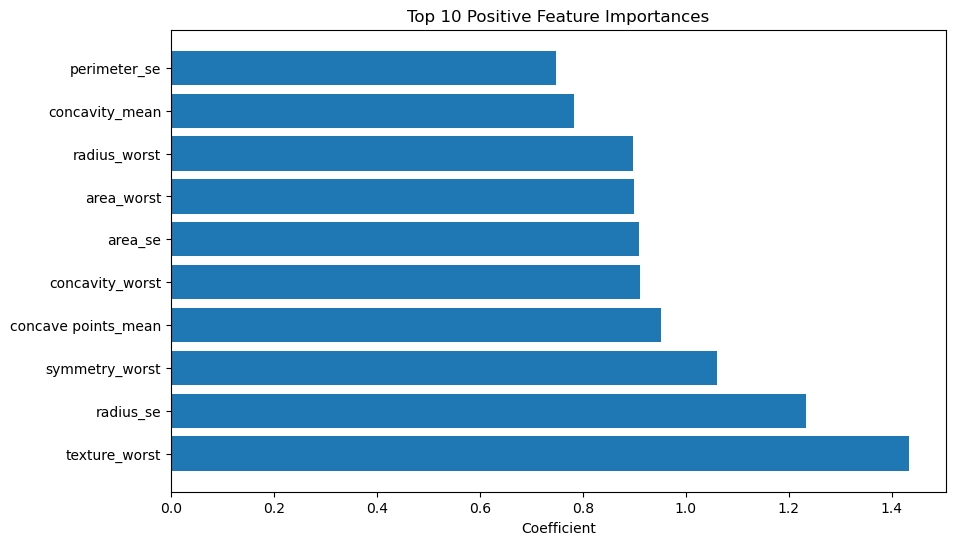

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title(
    "Top 10 Positive Feature Importances"
)

plt.xlabel("Coefficient")

plt.show()

In [120]:
#towards benign
coef_df.sort_values(
    by="Coefficient"
).head(10)
coef_df["Abs_Coefficient"] = abs(
    coef_df["Coefficient"]
)


In [121]:
#using absolute strngth
coef_df["Abs_Coefficient"] = abs(
    coef_df["Coefficient"]
)

coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Abs_Coefficient
21,texture_worst,1.434093,1.434093
10,radius_se,1.233325,1.233325
28,symmetry_worst,1.061264,1.061264
7,concave points_mean,0.952813,0.952813
26,concavity_worst,0.911406,0.911406
13,area_se,0.909029,0.909029
15,compactness_se,-0.906925,0.906925
23,area_worst,0.900477,0.900477
20,radius_worst,0.896968,0.896968
6,concavity_mean,0.782298,0.782298


In [122]:
#PREDICTING CANCER FOR NEW PATIENT


In [137]:
#LETS USE THE FIRST RAW FOR PREDICTING ASSUMUNG AS NEW RECORD
new_patient=X.iloc[[10]]
new_patient

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,19.19,33.88,123.8,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452


In [138]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Learn mean/std from training data and scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale new patient data using the SAME scaler
new_patient_scaled = scaler.transform(new_patient)

In [139]:
#if logistic was good
prediction = log_model.predict(
    new_patient_scaled
)

print(prediction)


[1]


In [140]:
if prediction[0] == 1:
    print("Malignant (Cancer)")
else:
    print("Benign (No Cancer)")

Malignant (Cancer)


In [141]:
probability = log_model.predict_proba(
    new_patient_scaled
)

benign_prob = probability[0][0]
malignant_prob = probability[0][1]

print(
    f"Benign Probability: {benign_prob:.2%}"
)

print(
    f"Malignant Probability: {malignant_prob:.2%}"
)

Benign Probability: 6.01%
Malignant Probability: 93.99%


In [142]:
#saving model (joblib or pickle is ok)
import joblib

In [143]:
joblib.dump(
    log_model,
    "breast_cancer_model.pkl"
)

['breast_cancer_model.pkl']

In [144]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [145]:
#loading the model 
loaded_model=joblib.load("breast_cancer_model.pkl")
loaded_scaler = joblib.load(
    "scaler.pkl"
)


In [146]:
print(type(loaded_model))
print(type(loaded_scaler))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [147]:
joblib.dump(
    knn_pca,
    "best_model.pkl"
)

['best_model.pkl']

In [148]:
#FINAL

In [151]:
import os

print(os.getcwd())

C:\Users\PC


In [154]:
import os

print(os.listdir("models"))

['breast_cancer_model.pkl', 'scaler.pkl']


In [153]:
print(os.path.exists("breast_cancer_model.pkl"))
print(os.path.exists("scaler.pkl"))

True
True


In [155]:
import os

print(os.getcwd())
print(os.path.abspath("models"))

C:\Users\PC
C:\Users\PC\models


In [159]:
#using streamlit

In [161]:
import joblib

model = joblib.load("models/breast_cancer_model.pkl")
scaler = joblib.load("models/scaler.pkl")
